# Explore `new_frames/`

Companion notebook to `collect_frames.ipynb`.  
Loads the per-activity `new_frames/<activity>/frames.npy` files and explores them **before** running H5 generation.

**What this notebook does**
1. Discover all `frames.npy` files and report shapes / sizes.
2. Per-feature statistics (x, y, z, intensity, speed) over real points.
3. 3-D scatter — one frame per activity.
4. Test point down-sampling: `pad_or_crop` vs `fps_sample`.
5. Test stacking: a window of `stacking_size` consecutive frames.

In [12]:
# =============================================================================
#  CONFIGURATION — edit these variables instead of a configs.yaml file
# =============================================================================

NEW_FRAMES_DIR = "new_frames"   # root folder that contains one sub-folder per activity
FRAMES_FNAME   = "frames.npy"  # filename inside each activity sub-folder

N_POINTS       = 64            # target points per frame after down-sampling
STACKING_SIZE  = 5             # number of consecutive frames to stack into one sample
STRIDE         = None          # sliding-window stride (None → no overlap, equals STACKING_SIZE)
USE_FPS        = True          # True → fps_sample  |  False → pad_or_crop

H5_FEATURES    = "x,y,z,intensity,speed"   # feature names (for axis labels)
# =============================================================================

In [13]:
# --- Imports ----------------------------------------------------------------
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401
from pathlib import Path

plt.rcParams['figure.dpi'] = 110
np.set_printoptions(suppress=True, precision=3)

# Make sure radar_utils.py is importable from the same directory
HERE = Path.cwd()
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))
from radar_utils import fps_sample, pad_or_crop

# Resolve paths and derived settings
FRAMES_ROOT    = (HERE / NEW_FRAMES_DIR).resolve()
STRIDE_EFF     = max(1, int(STRIDE)) if STRIDE is not None else STACKING_SIZE
feature_names  = [f.strip() for f in H5_FEATURES.split(',')]

print(f"new_frames dir : {FRAMES_ROOT}")
print(f"n_points       : {N_POINTS}")
print(f"stacking_size  : {STACKING_SIZE}")
print(f"stride         : {STRIDE_EFF}")
print(f"use_fps        : {USE_FPS}")

assert FRAMES_ROOT.is_dir(), (
    f"{FRAMES_ROOT} not found.  Run collect_frames.ipynb first, "
    f"or update NEW_FRAMES_DIR in Cell 1."
)

new_frames dir : D:\Hossein\Point_Cloud\datasets\git_hub_Release_our_dataset\new_frames
n_points       : 64
stacking_size  : 5
stride         : 5
use_fps        : True


## 1. Discover combined-frame files

In [14]:
activities = sorted(p.name for p in FRAMES_ROOT.iterdir() if p.is_dir())
rows = []
for act in activities:
    fp = FRAMES_ROOT / act / FRAMES_FNAME
    if not fp.is_file():
        print(f"  [missing] {fp}")
        continue
    arr      = np.load(fp, mmap_mode='r')
    size_mb  = fp.stat().st_size / 1024**2
    rows.append(dict(activity=act, path=fp, shape=tuple(arr.shape),
                     dtype=str(arr.dtype), size_mb=size_mb))

col_w = max(len(r['activity']) for r in rows) + 2
print(f'\n  {"Activity":<{col_w}} {"Shape":>22} {"dtype":>9} {"MB":>8}')
print('  ' + '-' * (col_w + 41))
for r in rows:
    print(f'  {r["activity"]:<{col_w}} {str(r["shape"]):>22} {r["dtype"]:>9} {r["size_mb"]:>8.1f}')
print('  ' + '-' * (col_w + 41))
tot_frames = sum(r['shape'][0] for r in rows)
tot_mb     = sum(r['size_mb']  for r in rows)
print(f'  {"TOTAL":<{col_w}} {tot_frames:>22,d} {"":>9} {tot_mb:>8.1f}')


  Activity                                        Shape     dtype       MB
  -----------------------------------------------------------------------
  Bowing (D)                            (5000, 1024, 5)   float32     97.7
  Lunge (toward left side)              (5000, 1024, 5)   float32     97.7
  Lunge (toward left-front)             (5000, 1024, 5)   float32     97.7
  Lunge (toward right side)             (5000, 1024, 5)   float32     97.7
  Lunge (toward right-front)            (5000, 1024, 5)   float32     97.7
  Mark time                             (5000, 1024, 5)   float32     97.7
  Picking Up Things                     (5000, 1024, 5)   float32     97.7
  Raising Hand Left                     (5000, 1024, 5)   float32     97.7
  Raising Hand Right                    (5000, 1024, 5)   float32     97.7
  Sitting                               (5000, 1024, 5)   float32     97.7
  Squat                                 (5000, 1024, 5)   float32     97.7
  Standing               

## 2. Per-feature statistics over real points

Loads each file lazily via memmap, masks `intensity > 0` (drops zero-padding rows), and aggregates min / max / mean / std per feature.

In [15]:
n_real = n_total = 0
feat_min = feat_max = feat_sum = feat_sumsq = None

for r in rows:
    arr  = np.load(r['path'], mmap_mode='r')           # (F, N_raw, 5)
    flat = arr.reshape(-1, arr.shape[-1])               # (F*N_raw, 5)
    mask = flat[:, 3] > 0
    real = np.asarray(flat[mask], dtype=np.float64)
    n_total += flat.shape[0]
    n_real  += real.shape[0]
    if real.shape[0] == 0:
        continue
    feat_min   = real.min(0) if feat_min   is None else np.minimum(feat_min,   real.min(0))
    feat_max   = real.max(0) if feat_max   is None else np.maximum(feat_max,   real.max(0))
    feat_sum   = real.sum(0) if feat_sum   is None else feat_sum   + real.sum(0)
    feat_sumsq = (real**2).sum(0) if feat_sumsq is None else feat_sumsq + (real**2).sum(0)

if n_real:
    mean = feat_sum / n_real
    std  = np.sqrt(np.clip(feat_sumsq / n_real - mean**2, 0, None))
    print(f'Real points (intensity > 0): {n_real:,} / {n_total:,}  '
          f'(zero-pad: {n_total - n_real:,}, {100*(n_total - n_real)/max(1, n_total):.1f}%)')
    print('-' * 62)
    for i, fn in enumerate(feature_names):
        print(f'  {fn:<12} min={feat_min[i]:>10.3f}  max={feat_max[i]:>10.3f}  '
              f'mean={mean[i]:>10.3f}  std={std[i]:>10.3f}')
else:
    print('No real points found.')

Real points (intensity > 0): 102,195,200 / 102,195,200  (zero-pad: 0, 0.0%)
--------------------------------------------------------------
  x            min=    -0.482  max=     0.457  mean=    -0.006  std=     0.015
  y            min=     0.000  max=     0.711  mean=     0.245  std=     0.167
  z            min=    -0.711  max=     0.456  mean=     0.006  std=     0.026
  intensity    min=   147.349  max=3934369.500  mean=889220.590  std=372583.535
  speed        min=    -2.602  max=     2.562  mean=     0.000  std=     0.040


## 3. 3-D scatter — one frame per activity

Middle frame of each activity, real points only, coloured by intensity.

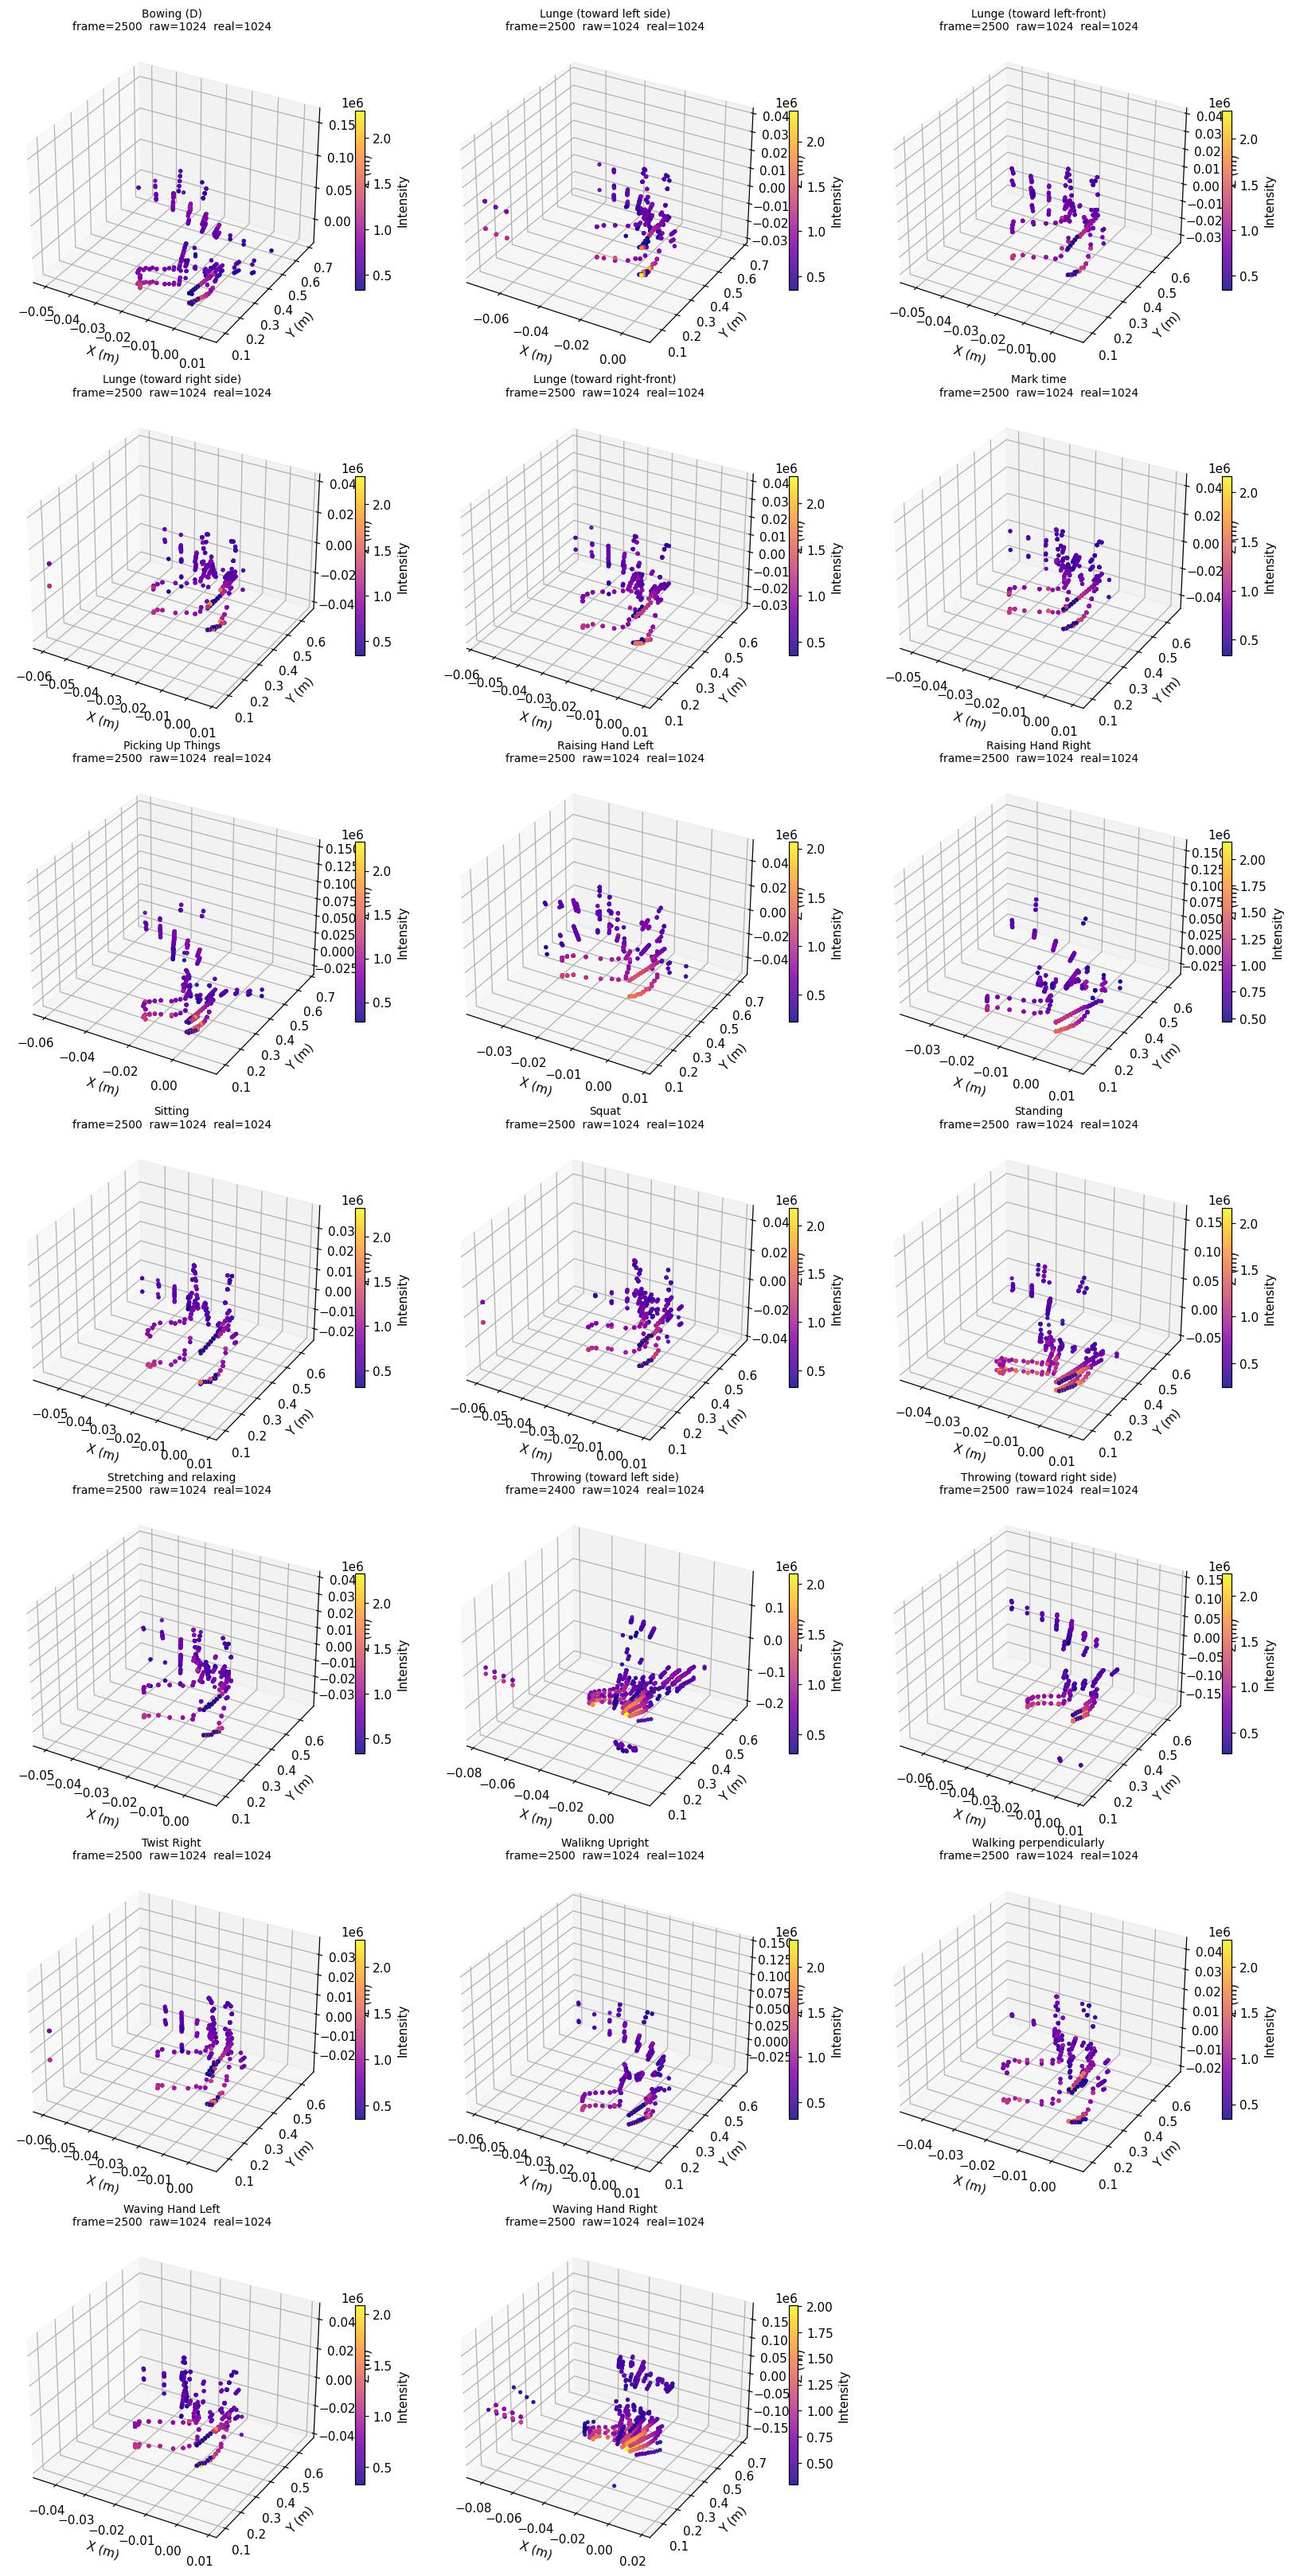

In [16]:
ncols = 3
nrows = int(np.ceil(len(rows) / ncols))
fig   = plt.figure(figsize=(5 * ncols, 4.2 * nrows))

for i, r in enumerate(rows):
    arr   = np.load(r['path'], mmap_mode='r')
    mid   = arr.shape[0] // 2
    frame = np.asarray(arr[mid])
    real  = frame[frame[:, 3] > 0]
    if real.size == 0:
        real = frame[:32]

    ax = fig.add_subplot(nrows, ncols, i + 1, projection='3d')
    sc = ax.scatter(real[:, 0], real[:, 1], real[:, 2],
                    c=real[:, 3], cmap='plasma', s=6, alpha=0.85)
    plt.colorbar(sc, ax=ax, shrink=0.55, label='Intensity')
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
    ax.set_title(f'{r["activity"]}\nframe={mid}  raw={frame.shape[0]}  real={len(real)}',
                 fontsize=9)

plt.tight_layout()
plt.show()

## 4. Down-sampling comparison — `pad_or_crop` vs `fps_sample`

Both functions return exactly `(N_POINTS, 5)`.  
We compare them on the same middle frame and time them.

Activity under test: Bowing (D)
  raw real points   : 1024
  pad_or_crop → (64, 5)   (0.00 ms)
  fps_sample  → (64, 5)   (5.00 ms)


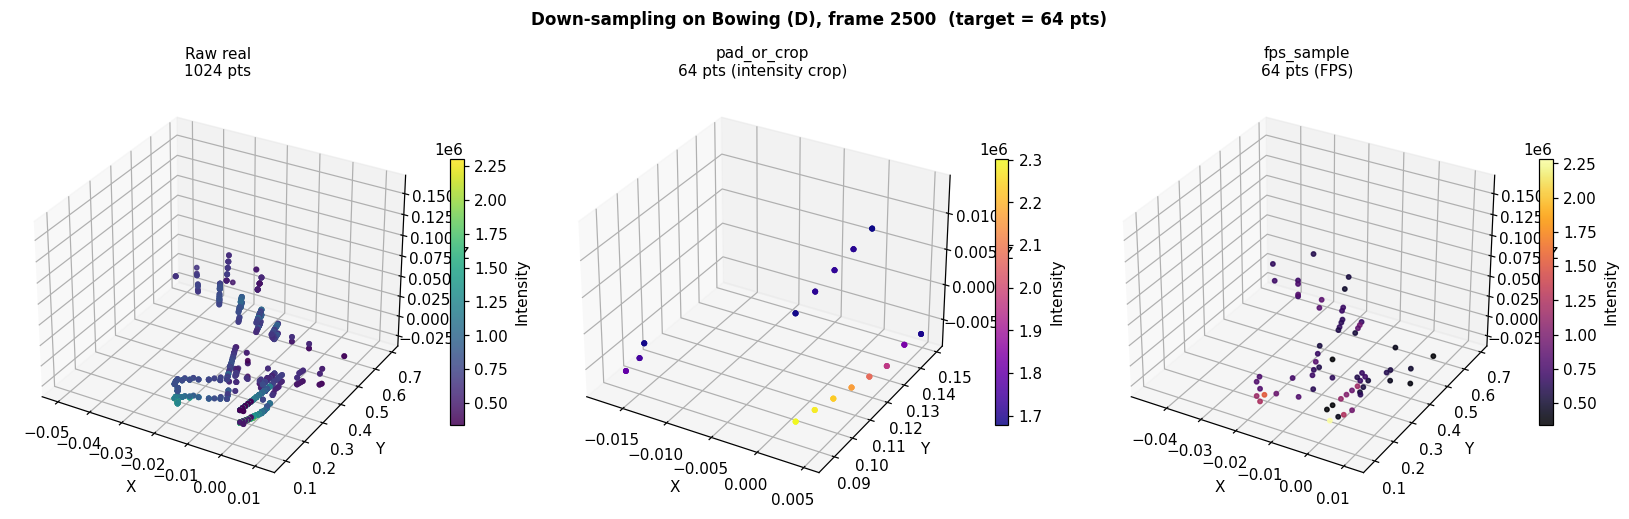

In [17]:
PICK_ACTIVITY = rows[0]['activity']   # ← change to any activity name
print(f'Activity under test: {PICK_ACTIVITY}')

arr   = np.load(FRAMES_ROOT / PICK_ACTIVITY / FRAMES_FNAME, mmap_mode='r')
mid   = arr.shape[0] // 2
frame = np.asarray(arr[mid])
real  = frame[frame[:, 3] > 0]
if real.shape[0] == 0:
    real = frame[:32]

t0 = time.time(); crop = pad_or_crop(real, N_POINTS); t_crop = time.time() - t0
t0 = time.time(); fps  = fps_sample (real, N_POINTS); t_fps  = time.time() - t0

print(f'  raw real points   : {real.shape[0]}')
print(f'  pad_or_crop → {crop.shape}   ({t_crop*1000:.2f} ms)')
print(f'  fps_sample  → {fps.shape}   ({t_fps*1000:.2f} ms)')

fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': '3d'})
for ax, pts, title, cmap in zip(
    axes,
    [real, crop, fps],
    [f'Raw real\n{real.shape[0]} pts',
     f'pad_or_crop\n{crop.shape[0]} pts (intensity crop)',
     f'fps_sample\n{fps.shape[0]} pts (FPS)'],
    ['viridis', 'plasma', 'inferno'],
):
    v = pts[pts[:, 3] > 0] if len(pts) else pts
    if v.shape[0]:
        sc = ax.scatter(v[:, 0], v[:, 1], v[:, 2], c=v[:, 3], cmap=cmap, s=8, alpha=0.85)
        plt.colorbar(sc, ax=ax, shrink=0.55, label='Intensity')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(title, fontsize=10)
fig.suptitle(f'Down-sampling on {PICK_ACTIVITY}, frame {mid}  (target = {N_POINTS} pts)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.1 Timing over 100 frames

In [18]:
N_TIME = min(100, arr.shape[0])
ts_crop = np.empty(N_TIME)
ts_fps  = np.empty(N_TIME)

for i in range(N_TIME):
    fr   = np.asarray(arr[i])
    fr_r = fr[fr[:, 3] > 0]
    if fr_r.shape[0] == 0:
        fr_r = fr[:8]
    t = time.time(); pad_or_crop(fr_r, N_POINTS); ts_crop[i] = time.time() - t
    t = time.time(); fps_sample (fr_r, N_POINTS); ts_fps[i]  = time.time() - t

print(f'pad_or_crop : {ts_crop.mean()*1000:6.2f} ± {ts_crop.std()*1000:5.2f} ms  (over {N_TIME} frames)')
print(f'fps_sample  : {ts_fps.mean()*1000:6.2f} ± {ts_fps.std()*1000:5.2f} ms  (over {N_TIME} frames)')
print(f'speed ratio : fps is ~{ts_fps.mean()/max(1e-9, ts_crop.mean()):.1f}x slower than pad_or_crop')

pad_or_crop :   0.10 ±  0.30 ms  (over 100 frames)
fps_sample  :   3.96 ±  1.02 ms  (over 100 frames)
speed ratio : fps is ~39.6x slower than pad_or_crop


## 5. Stacking — `stacking_size` consecutive frames

A training sample is `stacking_size` frames concatenated along the point axis (each frame down-sampled to `N_POINTS` first).  
The active down-sampler is controlled by `USE_FPS` in Cell 1.

window      : Bowing (D)  frames 2498–2502
per-frame   : FPS → 64 pts
stacked     : (320, 5)  (320 real, 0 zero-pad)


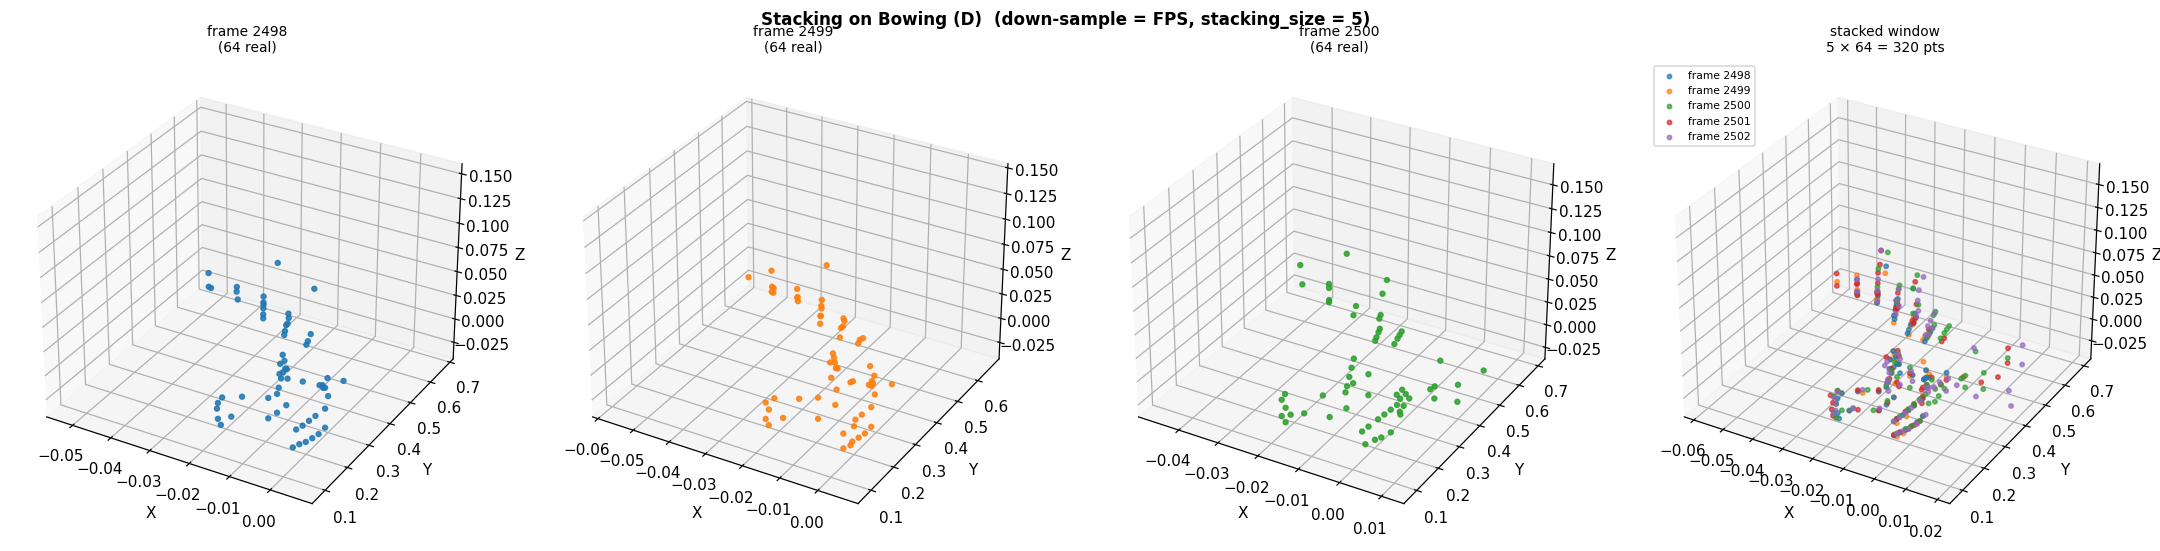

In [19]:
downsample_fn = fps_sample if USE_FPS else pad_or_crop
fn_name       = 'FPS' if USE_FPS else 'pad_or_crop'

start  = max(0, min(arr.shape[0] // 2 - STACKING_SIZE // 2,
                    arr.shape[0] - STACKING_SIZE))
window = np.asarray(arr[start : start + STACKING_SIZE])   # (S, N_raw, 5)

frames_ds = []
for fi in range(STACKING_SIZE):
    fr   = window[fi]
    fr_r = fr[fr[:, 3] > 0]
    if fr_r.shape[0] == 0:
        fr_r = fr[:4]
    frames_ds.append(downsample_fn(fr_r, N_POINTS))

stacked        = np.concatenate(frames_ds, axis=0)         # (S * N_POINTS, 5)
n_real_stacked = int((stacked[:, 3] > 0).sum())

print(f'window      : {PICK_ACTIVITY}  frames {start}–{start+STACKING_SIZE-1}')
print(f'per-frame   : {fn_name} → {N_POINTS} pts')
print(f'stacked     : {stacked.shape}  ({n_real_stacked} real, '
      f'{stacked.shape[0]-n_real_stacked} zero-pad)')

n_show = min(3, STACKING_SIZE)
fig, axes = plt.subplots(1, n_show + 1, figsize=(5 * (n_show + 1), 5),
                          subplot_kw={'projection': '3d'})
tab = [plt.cm.tab10(i) for i in range(10)]

for i in range(n_show):
    fr = frames_ds[i]
    v  = fr[fr[:, 3] > 0]
    if v.shape[0]:
        axes[i].scatter(v[:, 0], v[:, 1], v[:, 2], color=tab[i % 10], s=10, alpha=0.85)
    axes[i].set_xlabel('X'); axes[i].set_ylabel('Y'); axes[i].set_zlabel('Z')
    axes[i].set_title(f'frame {start+i}\n({(fr[:, 3]>0).sum()} real)', fontsize=9)

ax_s = axes[-1]
for i, fr in enumerate(frames_ds):
    v = fr[fr[:, 3] > 0]
    if v.shape[0]:
        ax_s.scatter(v[:, 0], v[:, 1], v[:, 2], color=tab[i % 10], s=8,
                     alpha=0.7, label=f'frame {start+i}')
ax_s.set_xlabel('X'); ax_s.set_ylabel('Y'); ax_s.set_zlabel('Z')
ax_s.set_title(f'stacked window\n{STACKING_SIZE} × {N_POINTS} = {stacked.shape[0]} pts', fontsize=9)
ax_s.legend(fontsize=7, loc='upper left')
fig.suptitle(f'Stacking on {PICK_ACTIVITY}  (down-sample = {fn_name}, stacking_size = {STACKING_SIZE})',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.1 Window count vs stride

In [20]:
for r in rows:
    n_frames = r['shape'][0]
    n_windows_no_overlap  = n_frames // STACKING_SIZE
    n_windows_with_stride = max(0, (n_frames - STACKING_SIZE) // STRIDE_EFF + 1)
    print(f"  {r['activity']:<20}  frames={n_frames:>5}  "
          f"no-overlap={n_windows_no_overlap:>4}  "
          f"stride={STRIDE_EFF}→{n_windows_with_stride:>4} windows")

  Bowing (D)            frames= 5000  no-overlap=1000  stride=5→1000 windows
  Lunge (toward left side)  frames= 5000  no-overlap=1000  stride=5→1000 windows
  Lunge (toward left-front)  frames= 5000  no-overlap=1000  stride=5→1000 windows
  Lunge (toward right side)  frames= 5000  no-overlap=1000  stride=5→1000 windows
  Lunge (toward right-front)  frames= 5000  no-overlap=1000  stride=5→1000 windows
  Mark time             frames= 5000  no-overlap=1000  stride=5→1000 windows
  Picking Up Things     frames= 5000  no-overlap=1000  stride=5→1000 windows
  Raising Hand Left     frames= 5000  no-overlap=1000  stride=5→1000 windows
  Raising Hand Right    frames= 5000  no-overlap=1000  stride=5→1000 windows
  Sitting               frames= 5000  no-overlap=1000  stride=5→1000 windows
  Squat                 frames= 5000  no-overlap=1000  stride=5→1000 windows
  Standing              frames= 5000  no-overlap=1000  stride=5→1000 windows
  Stretching and relaxing  frames= 5000  no-overlap=1000

---
## 6. (Optional) Export to H5

Run this cell to pack all activities into a single `.h5` file ready for model training.  
Set `H5_OUT_PATH` below, then run. The file will be created in the same directory as the notebook.

**Schema written**
```
/points      float32  (N_samples, STACKING_SIZE * N_POINTS, 5)
/class_id    int32    (N_samples,)
/sample_id   int32    (N_samples,)
/class_name  bytes    (N_samples,)
/split       bytes    (N_samples,)   "train" | "val" | "test"
```
Splits are assigned randomly with the ratios in `H5_SPLIT`.

In [ ]:
# =============================================================================
#  H5 EXPORT — configure and run this cell to generate a dataset file
# =============================================================================
H5_OUT_PATH = "dataset.h5"           # output path (relative to notebook)
H5_SPLIT    = (0.75, 0.05, 0.20)     # train / val / test fractions
H5_SEED     = 42                     # random seed for split assignment
# =============================================================================

import h5py
from pathlib import Path

downsample_fn = fps_sample if USE_FPS else pad_or_crop
fn_name       = 'FPS' if USE_FPS else 'pad_or_crop'
rng           = np.random.default_rng(H5_SEED)

# Build class map from discovered activity folders
class_map = {act: i for i, act in enumerate(sorted(r['activity'] for r in rows))}
print(f'Classes ({len(class_map)}): {class_map}')
print(f'Down-sampler : {fn_name}')
print(f'N_POINTS     : {N_POINTS}  |  STACKING_SIZE : {STACKING_SIZE}  |  STRIDE : {STRIDE_EFF}')
print(f'Output       : {Path(H5_OUT_PATH).resolve()}\n')

all_points     = []
all_class_ids  = []
all_sample_ids = []
all_class_names = []
sample_id = 0

for r in rows:
    arr     = np.load(r['path'], mmap_mode='r')   # (F, N_raw, 5)
    cid     = class_map[r['activity']]
    n_frames = arr.shape[0]

    # Sliding window over frames
    starts = range(0, n_frames - STACKING_SIZE + 1, STRIDE_EFF)
    for start in starts:
        frames_ds = []
        for fi in range(STACKING_SIZE):
            fr   = np.asarray(arr[start + fi])        # (N_raw, 5)
            fr_r = fr[fr[:, 3] > 0]                   # real points only
            if fr_r.shape[0] == 0:
                fr_r = fr[:4]
            frames_ds.append(downsample_fn(fr_r, N_POINTS))
        stacked = np.concatenate(frames_ds, axis=0)   # (STACKING_SIZE * N_POINTS, 5)
        all_points.append(stacked)
        all_class_ids.append(cid)
        all_sample_ids.append(sample_id)
        all_class_names.append(r['activity'])
        sample_id += 1

    print(f'  {r["activity"]:<20}  {len(starts):>5} windows')

# Stack into arrays
points_arr  = np.stack(all_points,     axis=0).astype(np.float32)  # (N, S*P, 5)
class_ids   = np.array(all_class_ids,  dtype=np.int32)
sample_ids  = np.array(all_sample_ids, dtype=np.int32)
class_names = np.array([s.encode('utf-8') for s in all_class_names])

# Assign splits
n_total   = len(points_arr)
perm      = rng.permutation(n_total)
t_end     = int(H5_SPLIT[0] * n_total)
v_end     = t_end + int(H5_SPLIT[1] * n_total)
split_arr = np.empty(n_total, dtype=object)
split_arr[perm[:t_end]]       = 'train'
split_arr[perm[t_end:v_end]]  = 'val'
split_arr[perm[v_end:]]       = 'test'
split_enc = np.array([s.encode('utf-8') for s in split_arr])

# Write H5
with h5py.File(H5_OUT_PATH, 'w') as f:
    f.create_dataset('points',     data=points_arr,  compression='gzip', compression_opts=4)
    f.create_dataset('class_id',   data=class_ids)
    f.create_dataset('sample_id',  data=sample_ids)
    f.create_dataset('class_name', data=class_names)
    f.create_dataset('split',      data=split_enc)
    f.attrs['class_map']   = str(class_map)
    f.attrs['num_classes'] = len(class_map)
    f.attrs['num_points']  = N_POINTS
    f.attrs['stacks']      = STACKING_SIZE
    f.attrs['features']    = H5_FEATURES
    f.attrs['source']      = 'lab_mmwave'

train_n = int((split_arr == 'train').sum())
val_n   = int((split_arr == 'val').sum())
test_n  = int((split_arr == 'test').sum())
size_mb = Path(H5_OUT_PATH).stat().st_size / 1024**2

print(f'\n✓  Saved {H5_OUT_PATH}  ({size_mb:.1f} MB)')
print(f'   Total samples : {n_total:,}  '
      f'(train={train_n:,}  val={val_n:,}  test={test_n:,})')
print(f'   points shape  : {points_arr.shape}  '
      f'(samples × {STACKING_SIZE}×{N_POINTS} pts × 5 features)')